# Data Analysis

## Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore") 
import logging
logging.disable(logging.CRITICAL)
import os
import pandas as pd
import numpy as np
import ast

%load_ext autoreload
%autoreload 2

import openpyxl
from openpyxl import load_workbook
from tqdm import tqdm_notebook as tqdm

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
import scikit_posthocs as sp
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from typing import Optional

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

## Pre-Processing

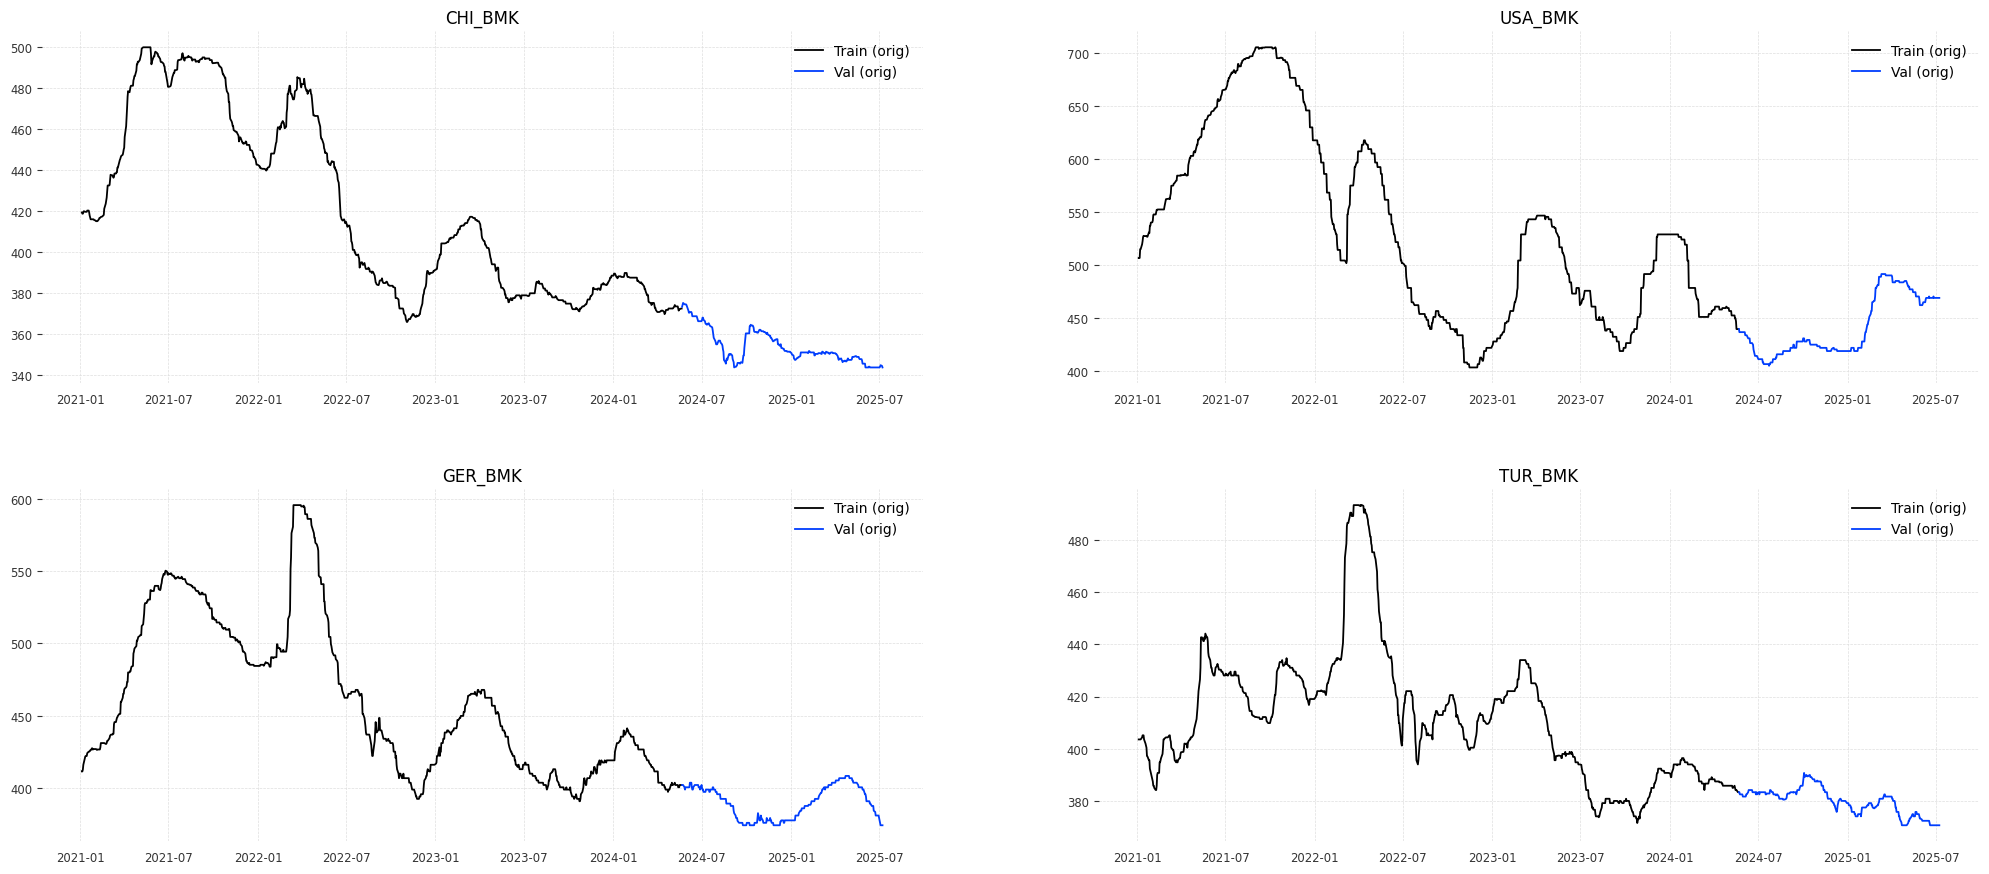

In [6]:
pd.plotting.register_matplotlib_converters()
warnings.filterwarnings("ignore")

# ============================================
# 🔧 PRÉ-PROCESSAMENTO E PLOTAGEM
# ============================================

# -------------------------------
# 0) Funções de Transformação (para Séries Pandas)
# -------------------------------
TRANSFORM_CFG = {
    "kind": "log1p",
    "shift": 0.0,
}

def forward_transform(series: pd.Series) -> pd.Series:
    k = TRANSFORM_CFG["kind"]; c = TRANSFORM_CFG["shift"]
    if k == "none": return series
    if k == "log": return np.log(series)
    if k == "log1p": return np.log1p(series)
    if k == "log_shift": return np.log(series + c)
    raise ValueError(f"Tipo de transformação desconhecido: {k}")

def inverse_transform(series: pd.Series) -> pd.Series:
    k = TRANSFORM_CFG["kind"]; c = TRANSFORM_CFG["shift"]
    if k == "none": return series
    if k == "log": return np.exp(series)
    if k == "log1p": return np.expm1(series)
    if k == "log_shift": return np.exp(series) - c
    raise ValueError(f"Tipo de transformação desconhecido: {k}")

# --------------------------------------
# 1) Carregamento e limpeza inicial
# --------------------------------------
try:
    df_full = pd.read_excel("dataset/ds_benchmark.xlsx")
    df_full["date"] = pd.to_datetime(df_full["date"])
    df_full.set_index("date", inplace=True)
except FileNotFoundError:
    print("Arquivo 'dataset/ds_benchmark.xlsx' não encontrado. Usando dados de exemplo para demonstração.")
    dates = pd.date_range(start="2020-01-01", periods=500, freq="B")
    data = {
        "chi_bmk": 100 + np.random.randn(500).cumsum() * 0.5,
        "usa_bmk": 120 + np.random.randn(500).cumsum() * 0.4,
        "ger_bmk": 150 + np.random.randn(500).cumsum() * 0.3,
        "tur_bmk": 80  + np.random.randn(500).cumsum() * 0.6,
    }
    df_full = pd.DataFrame(data, index=dates)

# Processamento comum para ambos os casos
df_full = df_full.asfreq("B").interpolate()

# --------------------------------------
# 2) Plot in 2x2
# --------------------------------------
output_dir = "output"
file_name = "Data_Analysis_Price"
file_path = os.path.join(output_dir, f"{file_name}.png")
TARGET_COLS = ["chi_bmk", "usa_bmk", "ger_bmk", "tur_bmk"]
fig, axes = plt.subplots(2, 2, figsize=(25, 10))
axes = axes.flatten()

for i, target_col in enumerate(TARGET_COLS):
    ax = axes[i]
    series_raw = df_full[target_col].copy()

    # Winsorization
    q01, q99 = series_raw.quantile([0.01, 0.99])
    series_raw.clip(q01, q99, inplace=True)

    # Transformação
    series_trans = forward_transform(series_raw)

    # Escalonamento
    scaler = RobustScaler()
    scaled_values = scaler.fit_transform(series_trans.values.reshape(-1, 1))
    series_scaled = pd.Series(scaled_values.flatten(), index=series_trans.index)

    # Divisão Treino/Validação
    train_size = int(len(series_scaled) * 0.75)
    train_scaled = series_scaled.iloc[:train_size]
    val_scaled = series_scaled.iloc[train_size:]

    # Transformação Inversa para plotagem
    train_unscaled = pd.Series(scaler.inverse_transform(train_scaled.values.reshape(-1, 1)).flatten(), index=train_scaled.index)
    val_unscaled = pd.Series(scaler.inverse_transform(val_scaled.values.reshape(-1, 1)).flatten(), index=val_scaled.index)
    train_raw = inverse_transform(train_unscaled)
    val_raw = inverse_transform(val_unscaled)

    # Plotagem
    ax.plot(train_raw.index, train_raw, label="Train (orig)")
    ax.plot(val_raw.index, val_raw, label="Val (orig)")
    ax.set_title(f"{target_col.upper()}", fontsize=12)
    ax.legend()
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Título geral e ajuste de espaçamento manual (alternativa ao tight_layout)
#fig.suptitle("Original Time Series", fontsize=16, y=0.98)
fig.subplots_adjust(top=0.92, hspace=0.3)
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show("benchmark_plots_2x2.png")

## Volalitity

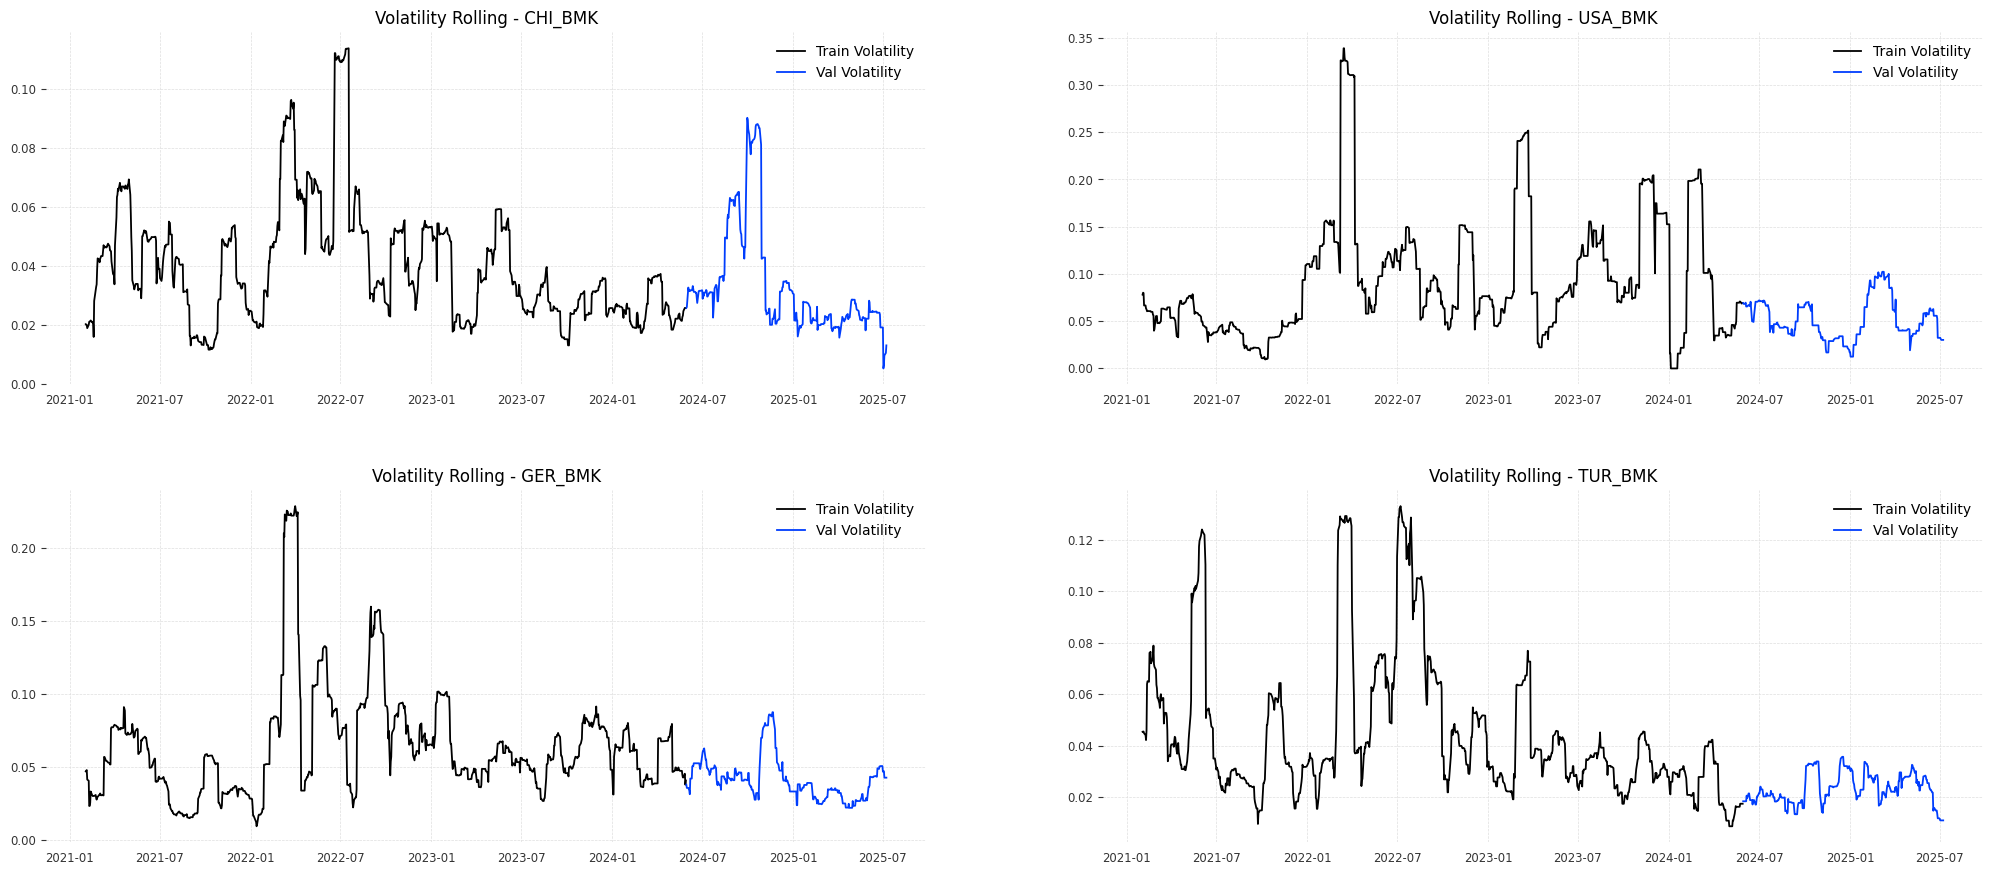

In [ ]:
# --------------------------------------
# 3) Volatility Rolling in 2x2
# --------------------------------------
output_dir = "output"
file_name = "Data_Analysis_Volatility"
file_path = os.path.join(output_dir, f"{file_name}.png")

fig_vol, axes_vol = plt.subplots(2, 2, figsize=(25, 10))
axes_vol = axes_vol.flatten()

for i, target_col in enumerate(TARGET_COLS):
    ax = axes_vol[i]
    series_raw = df_full[target_col].copy()

    # Winsorization
    q01, q99 = series_raw.quantile([0.01, 0.99])
    series_raw.clip(q01, q99, inplace=True)

    # Volatility rolling
    vol_rolling = series_raw.pct_change().rolling(window=21).std() * np.sqrt(252)
    vol_rolling.dropna(inplace=True)

    # Transformation
    vol_trans = forward_transform(vol_rolling)

    # Scalation
    scaler = RobustScaler()
    scaled_values = scaler.fit_transform(vol_trans.values.reshape(-1, 1))
    vol_scaled = pd.Series(scaled_values.flatten(), index=vol_trans.index)

    # Train / Test
    train_size = int(len(vol_scaled) * 0.75)
    train_scaled = vol_scaled.iloc[:train_size]
    val_scaled = vol_scaled.iloc[train_size:]

    # Inverse Transformation for Plotting
    train_unscaled = pd.Series(scaler.inverse_transform(train_scaled.values.reshape(-1, 1)).flatten(), index=train_scaled.index)
    val_unscaled = pd.Series(scaler.inverse_transform(val_scaled.values.reshape(-1, 1)).flatten(), index=val_scaled.index)
    train_vol = inverse_transform(train_unscaled)
    val_vol = inverse_transform(val_unscaled)

    # Plot
    ax.plot(train_vol.index, train_vol, label="Train Volatility")
    ax.plot(val_vol.index, val_vol, label="Val Volatility")
    ax.set_title(f"Volatility Rolling - {target_col.upper()}", fontsize=12)
    ax.legend()
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

fig_vol.subplots_adjust(top=0.92, hspace=0.3)
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

## Decomposition

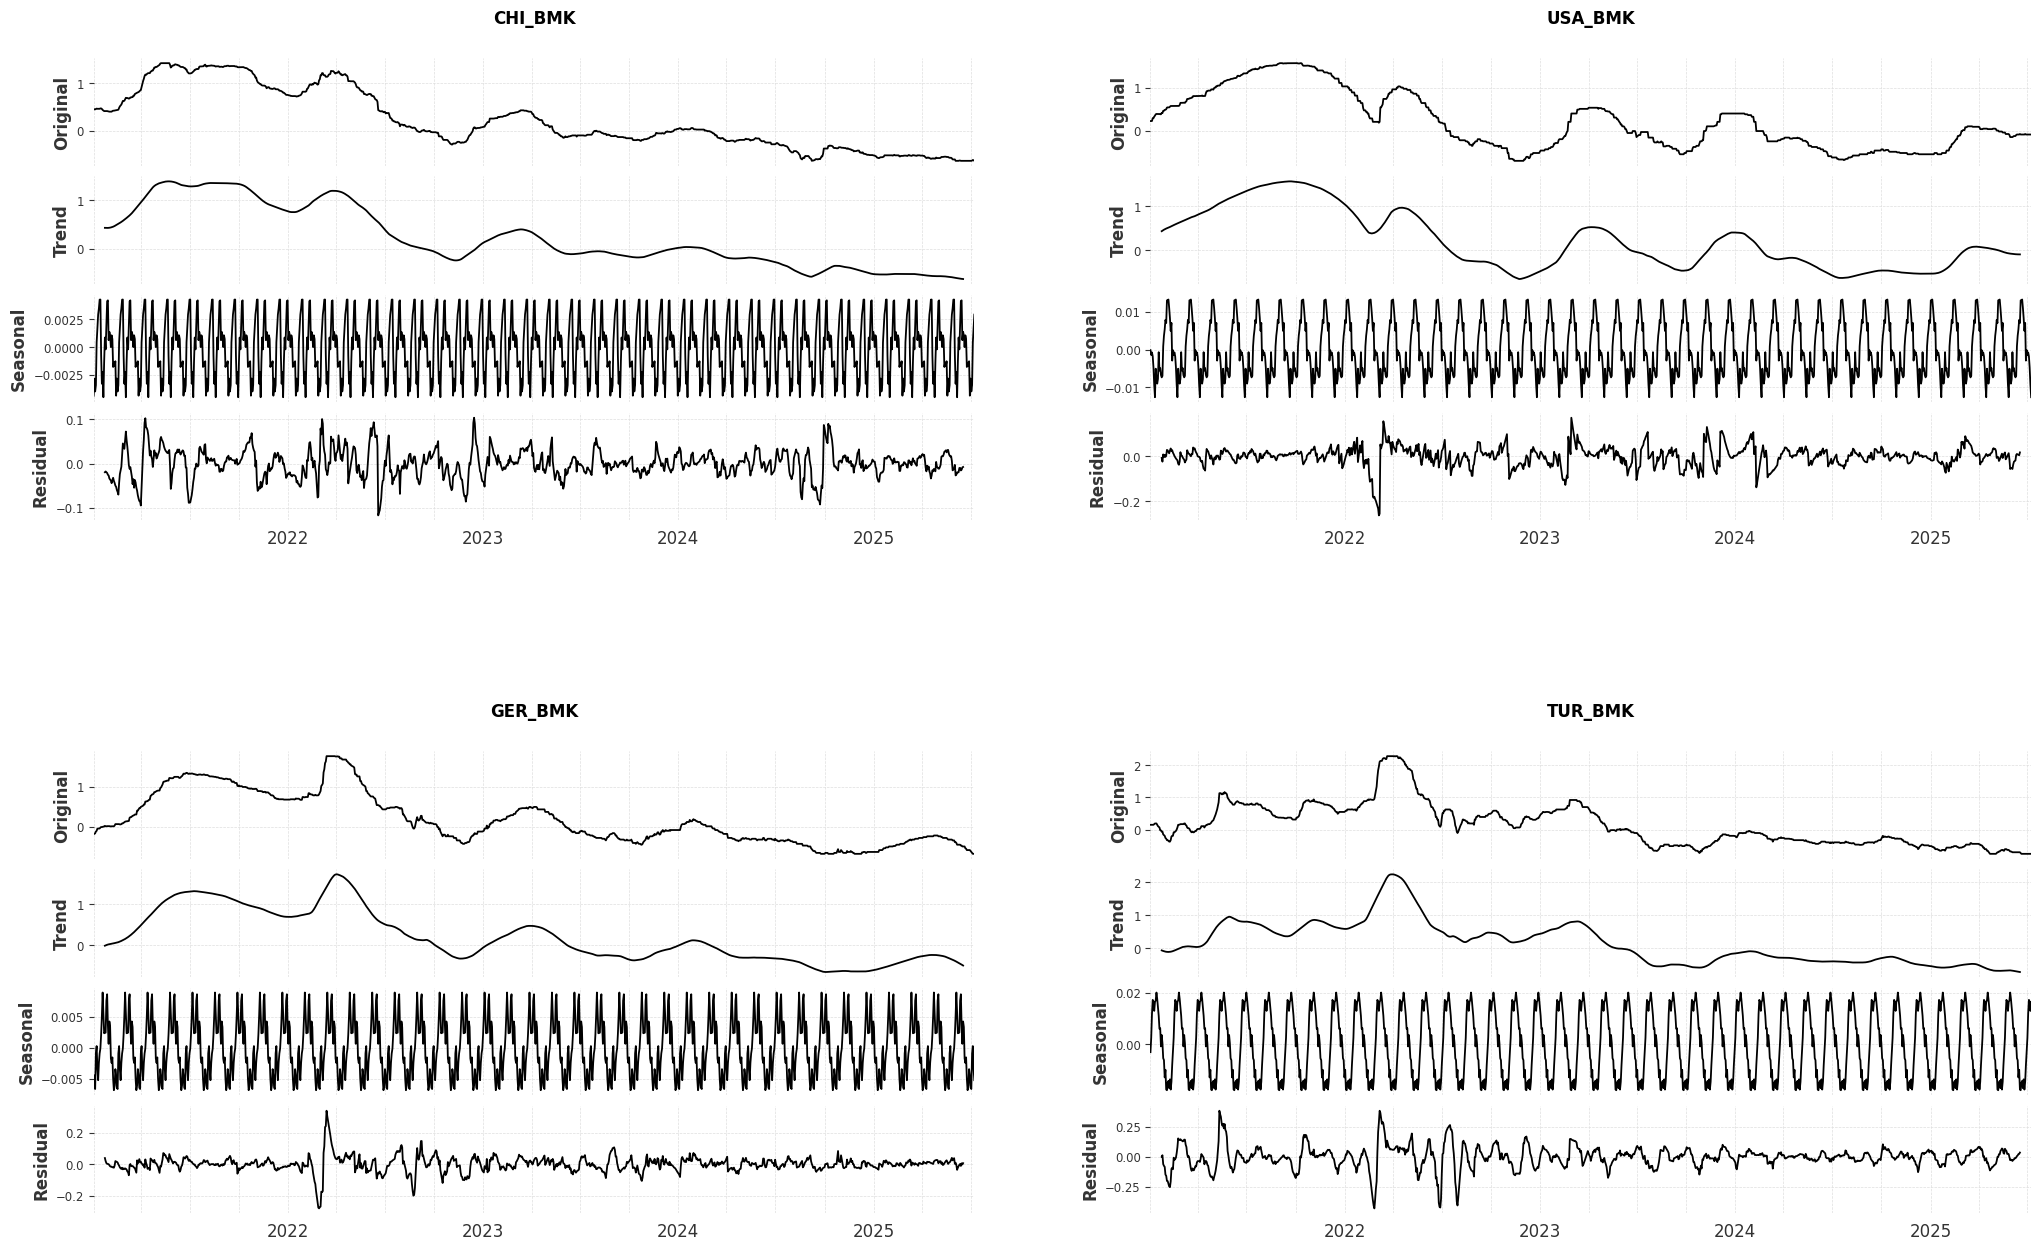

In [5]:
output_dir = "output"
file_name = "Data_Analysis_Decomposition"
file_path = os.path.join(output_dir, f"{file_name}.png")

pd.plotting.register_matplotlib_converters()
warnings.filterwarnings("ignore")

# ============================================
# Decomposition
# ============================================

# -------------------------------
# Transforming
# -------------------------------
TRANSFORM_CFG = {
    "kind": "log1p",
    "shift": 0.0,
}

def forward_transform(series: pd.Series) -> pd.Series:
    k = TRANSFORM_CFG["kind"]; c = TRANSFORM_CFG["shift"]
    if k == "none": return series
    if k == "log": return np.log(series)
    if k == "log1p": return np.log1p(series)
    if k == "log_shift": return np.log(series + c)
    raise ValueError(f"Error: {k}")

# --------------------------------------
# Loading
# --------------------------------------
try:
    df_full = pd.read_excel("dataset/ds_benchmark.xlsx")
    df_full["date"] = pd.to_datetime(df_full["date"])
    df_full.set_index("date", inplace=True)
except FileNotFoundError:
    print("File not found!")
    dates = pd.date_range(start="2020-01-01", periods=500, freq="B")
    data = {
        "chi_bmk": 100 + np.random.randn(500).cumsum() * 0.5,
        "usa_bmk": 120 + np.random.randn(500).cumsum() * 0.4,
        "ger_bmk": 150 + np.random.randn(500).cumsum() * 0.3,
        "tur_bmk": 80  + np.random.randn(500).cumsum() * 0.6,
    }
    df_full = pd.DataFrame(data, index=dates)

df_full = df_full.asfreq("B").interpolate()

# --------------------------------------
# Plot in 2x2
# --------------------------------------
TARGET_COLS = ["chi_bmk", "usa_bmk", "ger_bmk", "tur_bmk"]
COMPONENTS = ["Original", "Trend", "Seasonal", "Residual"]

fig = plt.figure(figsize=(25, 15))

outer_grid = gridspec.GridSpec(2, 2, figure=fig, wspace=0.2, hspace=0.5)

for i, target_col in enumerate(TARGET_COLS):
    series_raw = df_full[target_col].copy()
    q01, q99 = series_raw.quantile([0.01, 0.99])
    series_raw.clip(q01, q99, inplace=True)
    series_trans = forward_transform(series_raw)
    scaler = RobustScaler()
    scaled_values = scaler.fit_transform(series_trans.values.reshape(-1, 1))
    series_scaled_pd = pd.Series(scaled_values.flatten(), index=series_trans.index)
    
    decomposition = seasonal_decompose(series_scaled_pd, model="additive", period=30)
    components_to_plot = [
        decomposition.observed,
        decomposition.trend,
        decomposition.seasonal,
        decomposition.resid
    ]

    inner_grid = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=outer_grid[i], hspace=0.1)

    ax_title = fig.add_subplot(outer_grid[i])
    ax_title.set_title(target_col.upper(), fontsize=12, fontweight='bold', pad=25)
    ax_title.axis('off')

    for j, comp_series in enumerate(components_to_plot):
        ax = fig.add_subplot(inner_grid[j])
        comp_series.plot(ax=ax)
        ax.set_ylabel(COMPONENTS[j], fontsize=12)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

        if j < 3:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labelsize=14)
            ax.set_xlabel("")
        else:
            ax.tick_params(axis='x', rotation=0, labelsize=12)
            ax.set_xlabel("")

plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()